<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB19 · Redes neuronales: el codo que lo cambia todo

**Parte 2 · Matemáticas y herramientas para robots — Lección 8**

> En el **NB18** una neurona aprendió a imitar al maestro del palo de escoba, bajando por la pendiente de su error con la **regla de la
> cadena**. Pero aquel maestro era fácil: su regla era una **suma con pesos** (−30 × inclinación − 8 × velocidad), justo lo que una neurona
> sabe hacer.

¿Y si el maestro hace algo **más complicado**? Una neurona sola es **lineal**: su respuesta, dibujada, es siempre una **recta**. No puede
**doblarse**. Y el mundo real está lleno de cosas que se doblan: motores que llegan a su límite, robots que reaccionan suave a un empujón
pequeño y fortísimo a uno grande, pasos que empiezan y terminan...

Hoy descubrirás el **ingrediente que falta**, el que anunciamos en el NB13 y el NB14: la **función de activación**. Es un "codo" diminuto que se
pone a la salida de cada neurona. Parece una tontería, pero es lo que convierte un montón de neuronas en una **red neuronal**: una máquina capaz
de aprender **casi cualquier forma**.

Al final de la lección habrás construido y entrenado tu propia red neuronal, escribiendo **a mano** su retropropagación. Y entenderás cómo es la
red que mueve a un humanoide de verdad.


## 1 · Un maestro que no es una recta

Imagina un maestro más realista para el palo de escoba. Sigue la regla de siempre (empujar −30 por cada grado de inclinación), pero su motor
tiene un **límite**: nunca puede empujar más de 40 hacia ningún lado (NB01, NB11: los motores no son superhéroes). Así que, cuando la inclinación es
grande, el empuje se queda **plano** en el máximo. (Para poder dibujarlo, esta vez el maestro solo mira la inclinación.)

Le pedimos al maestro que diga qué empuje usaría en **61 inclinaciones** distintas, desde −3 hasta +3 grados. `np.linspace(-3, 3, 61)` fabrica
esos 61 números repartidos por igual entre −3 y 3 (*linspace* = "espacio lineal"), y `np.clip` (NB15) aplica el límite:


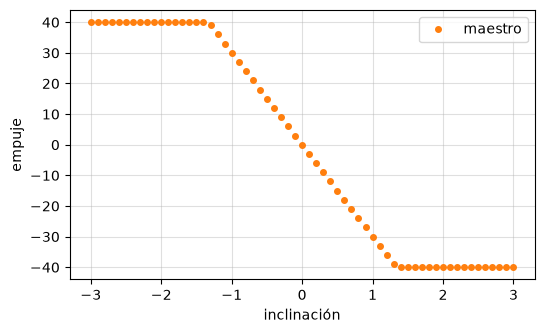

In [1]:
import numpy as np
import matplotlib.pyplot as plt

inclinaciones = np.linspace(-3, 3, 61)
empujes_del_maestro = np.clip(-30 * inclinaciones, -40, 40)

plt.figure(figsize=(6, 3.5))
plt.plot(inclinaciones, empujes_del_maestro, "o", color="tab:orange", markersize=4, label="maestro")
plt.grid(True, alpha=0.4)
plt.xlabel("inclinación")
plt.ylabel("empuje")
plt.legend()
plt.show()

(`label` y `plt.legend()` ponen una pequeña leyenda que dice qué es cada cosa.)

La forma tiene **tres tramos**: plana arriba (empujando +40 cuando el palo se inclina mucho hacia un lado), una rampa en el medio (la regla −30 ×
inclinación), y plana abajo (−40). La rampa termina en dos **esquinas**, donde el motor llega a su límite: en ±4/3 de grado (porque 30 × 4/3 = 40).

¿Puede una neurona lineal imitar esto?


## 2 · La neurona lineal no puede doblarse

Entrenemos una neurona lineal (un peso y un sesgo) con el descenso por gradiente del NB18, exactamente igual que entonces:

Peso aprendido: -18.42 | sesgo: 0.0 | pérdida: 81.5


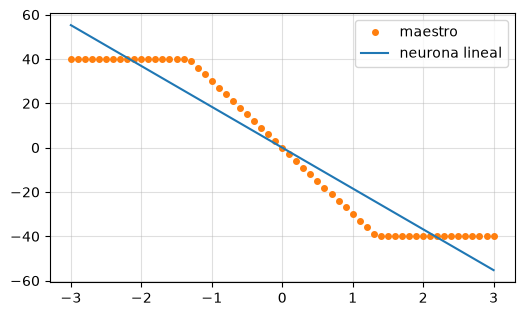

In [2]:
w, b = 0.0, 0.0
for paso in range(2000):
    errores = (w * inclinaciones + b) - empujes_del_maestro
    w = w - 0.05 * 2 * np.mean(errores * inclinaciones)
    b = b - 0.05 * 2 * np.mean(errores)

perdida_lineal = np.mean(((w * inclinaciones + b) - empujes_del_maestro) ** 2)
print("Peso aprendido:", round(w, 2), "| sesgo:", round(b, 2), "| pérdida:", round(perdida_lineal, 1))

plt.figure(figsize=(6, 3.5))
plt.plot(inclinaciones, empujes_del_maestro, "o", color="tab:orange", markersize=4, label="maestro")
plt.plot(inclinaciones, w * inclinaciones + b, color="tab:blue", label="neurona lineal")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

La neurona ha hecho lo mejor que puede: una **recta** con pendiente −18,4, que pasa "por en medio" de los puntos. Pero no puede seguir la forma: se
queda **corta** en el centro (donde el maestro tiene pendiente −30) y **se pasa** en los extremos (donde el maestro está plano). La pérdida se atasca en
**81,5**, y por mucho que entrenemos, **no bajará más**: no hay ninguna recta que pase por esos tres tramos.

No es un problema de entrenar más, ni de la tasa. Es un **límite de la máquina**: una neurona lineal **solo sabe hacer rectas**.


## 3 · ¿Y si apilamos neuronas lineales?

Una idea natural: si una neurona no basta, pongamos **muchas**, en **capas** (NB14). Una capa de 3 neuronas que reciben la inclinación, y luego una
neurona final que combina sus 3 salidas. Con pesos al azar, a ver qué forma sale:


In [3]:
generador = np.random.default_rng(7)
pesos_capa1 = generador.uniform(-2, 2, size=3)       # 3 neuronas, cada una con 1 peso...
sesgos_capa1 = generador.uniform(-2, 2, size=3)      # ...y su sesgo
pesos_capa2 = generador.uniform(-2, 2, size=3)       # la neurona final combina las 3

def dos_capas_lineales(x):
    salida = 0
    for j in range(3):
        intermedio = pesos_capa1[j] * x + sesgos_capa1[j]     # neurona j de la capa 1
        salida = salida + pesos_capa2[j] * intermedio          # la capa 2 los combina
    return salida

for x in [-2, 0, 2]:
    pendiente_aqui = (dos_capas_lineales(x + 0.001) - dos_capas_lineales(x - 0.001)) / 0.002
    print("en x =", x, "-> pendiente", round(pendiente_aqui, 4))

en x = -2 -> pendiente 2.3617
en x = 0 -> pendiente 2.3617
en x = 2 -> pendiente 2.3617


La pendiente es **la misma en todas partes**. Es decir: ¡dos capas lineales siguen dando **una recta**!

¿Por qué? Por los **engranajes** del NB18. La entrada pasa por un eslabón que multiplica (y suma algo), y luego por otro que multiplica (y suma algo).
Multiplicar y luego multiplicar es lo mismo que **multiplicar una sola vez** (por el producto de los dos). Por muchas capas lineales que apiles, el
resultado es siempre equivalente a **una sola** capa lineal: una recta. Una torre de neuronas lineales es tan "tiesa" como una sola.

Para poder **doblarse**, necesitamos algo que **no sea** multiplicar y sumar.


## 4 · El ingrediente que faltaba: el codo (ReLU)

El ingrediente es ridículamente sencillo. A la salida de cada neurona se le aplica esta regla:

> **Si el número es positivo, déjalo pasar. Si es negativo, conviértelo en 0.**

En Python: `max(0, x)`. Con NumPy, para un array entero: `np.maximum(0, x)`. Esta regla se llama **ReLU** (de las siglas en inglés de "unidad lineal
rectificada", un nombre muy pomposo para algo tan simple). Es una **función de activación**: decide cuánto se "activa" la neurona. Dibujémosla:


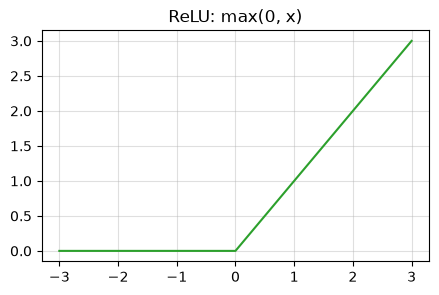

In [4]:
def relu(x):
    return np.maximum(0, x)

xs = np.linspace(-3, 3, 61)
plt.figure(figsize=(5, 3))
plt.plot(xs, relu(xs), color="tab:green")
plt.grid(True, alpha=0.4)
plt.title("ReLU: max(0, x)")
plt.show()

Plana en 0 a la izquierda, rampa hacia arriba a la derecha, y en medio... **un codo**. Como una **bisagra** (NB01): dos tramos rectos unidos por una
articulación. Y esa bisagra es justo lo que no tenían las neuronas lineales: un sitio donde **doblarse**.

Recuerda también el perceptrón del NB13: "si el resultado es mayor que 0, se activa". La ReLU es su versión suave: si es mayor que 0, deja pasar **cuánto**;
si no, nada. Una neurona con activación funciona así:

```
   neurona con activación  =  ReLU( pesos · entradas + sesgo )
                                    └── la neurona del NB13 ──┘
```


## 5 · Construir la curva del maestro con codos

¿Cómo se usan los codos para construir formas? Igual que con piezas de LEGO: cada neurona con ReLU aporta **un codo** en el sitio que digan su peso y su
sesgo, y la neurona final los **suma**, cada uno con su peso. Sumando codos colocados en sitios distintos se puede construir **cualquier forma hecha de
tramos rectos**.

De hecho, la forma del maestro se puede construir **exactamente** con solo **dos codos**. Te enseño la receta (pensada a mano):

```
   empuje = 40  −  30 × ReLU(inclinación + 4/3)  +  30 × ReLU(inclinación − 4/3)
```

- El **40** es el tramo plano de la izquierda.
- El primer codo "se enciende" en la inclinación −4/3 y, a partir de ahí, va restando 30 por cada grado: la **rampa**.
- El segundo codo se enciende en +4/3 y suma 30 por cada grado, **cancelando** la rampa: el tramo **plano** de la derecha.

Comprobémoslo:


In [5]:
red_a_mano = 40 - 30 * relu(inclinaciones + 4/3) + 30 * relu(inclinaciones - 4/3)

print("Mayor diferencia con el maestro:", np.max(np.abs(red_a_mano - empujes_del_maestro)))

Mayor diferencia con el maestro: 2.1316282072803006e-14


(`np.abs` quita el signo a cada número: es el "valor absoluto", la distancia al cero.)

La mayor diferencia es un número minúsculo (ruido de decimales): **¡imitación perfecta!** Con **dos** neuronas con ReLU y una neurona final, hemos hecho lo
que ninguna cantidad de neuronas lineales podía hacer. Eso es una **red neuronal**:

```
                      ┌─► neurona 1 → ReLU ─┐
   inclinación ───────┤                      ├──► neurona final ──► empuje
                      └─► neurona 2 → ReLU ─┘
      ENTRADA            CAPA OCULTA            SALIDA
```

A la capa del medio se le llama **capa oculta** (porque sus números no se ven desde fuera: ni son la entrada ni la salida). Y aquí está la gran pregunta:
yo he diseñado los pesos a mano, pensando. **¿Puede la red encontrarlos sola, aprendiendo de los ejemplos?**


## 6 · La red aprende sola: retropropagación con un eslabón más

Vamos a construir una red con **8 neuronas** en la capa oculta (más de las 2 necesarias, para darle margen), empezar con pesos **al azar**, y entrenarla con
descenso por gradiente, como en el NB18. Solo necesitamos las pendientes de **todos** los pesos. Y para eso, la **regla de la cadena** (NB18), con la cadena un
poco más larga.

Para un peso de la **capa oculta** (por ejemplo, el peso de entrada de la neurona j), la cadena de engranajes es:

```
   peso ──► z (lo que suma la neurona) ──► ReLU(z) ──► predicción ──► error ──► error²
            × inclinación                  × (0 o 1)    × peso de        × 1       × 2 × error
                                                          salida de j
```

Todos los eslabones ya los conoces, menos uno: **la pendiente de la ReLU**. Y es facilísima, mirando su dibujo: a la izquierda del codo es plana (pendiente
**0**), y a la derecha es una rampa de pendiente **1**. Así que:

> **pendiente de la ReLU = 1 si la neurona estaba "encendida" (z > 0), y 0 si estaba "apagada".**

Tiene un sentido precioso: si una neurona estaba apagada para un ejemplo, **no influyó** en la predicción, así que no tiene culpa de ese error y sus pesos de
entrada no se tocan. Multiplicando los eslabones, para cada ejemplo:

```
   pendiente del peso de entrada de j = 2 × error × (peso de salida de j) × (1 si encendida, si no 0) × inclinación
   pendiente del sesgo de j           = 2 × error × (peso de salida de j) × (1 si encendida, si no 0)
   pendiente del peso de salida de j  = 2 × error × ReLU(z de j)
```

(y luego, la **media** sobre todos los ejemplos). Lo escribimos con un bucle sobre las 8 neuronas (NumPy hace los 61 ejemplos a la vez). Es la celda más
larga del curso hasta ahora, pero cada línea es algo que ya conoces; léela con los comentarios:


In [6]:
ocultas = 8
generador = np.random.default_rng(0)
pesos_entrada = generador.uniform(-1, 1, size=ocultas)     # un peso por neurona oculta
sesgos_ocultos = generador.uniform(-1, 1, size=ocultas)    # un sesgo por neurona oculta
pesos_salida = generador.uniform(-1, 1, size=ocultas)      # cómo combina la salida a cada una
sesgo_salida = 0.0

def predecir(x):
    total = sesgo_salida
    for j in range(ocultas):
        total = total + pesos_salida[j] * relu(pesos_entrada[j] * x + sesgos_ocultos[j])
    return total

tasa = 0.003
historial = []
for paso in range(5000):
    # 1. hacia delante: lo que suma cada neurona (z), su activación, y la predicción
    zs = []
    activaciones = []
    for j in range(ocultas):
        z = pesos_entrada[j] * inclinaciones + sesgos_ocultos[j]
        zs.append(z)
        activaciones.append(relu(z))
    prediccion = sesgo_salida
    for j in range(ocultas):
        prediccion = prediccion + pesos_salida[j] * activaciones[j]
    errores = prediccion - empujes_del_maestro
    historial.append(np.mean(errores ** 2))

    # 2. hacia atrás: la regla de la cadena para cada neurona (la retropropagación)
    for j in range(ocultas):
        encendida = zs[j] > 0                                    # True/False para cada ejemplo (vale 1 o 0)
        culpa = 2 * errores * pesos_salida[j] * encendida        # la parte común de la cadena
        pendiente_entrada = np.mean(culpa * inclinaciones)
        pendiente_sesgo = np.mean(culpa)
        pendiente_salida = np.mean(2 * errores * activaciones[j])
        pesos_entrada[j] = pesos_entrada[j] - tasa * pendiente_entrada
        sesgos_ocultos[j] = sesgos_ocultos[j] - tasa * pendiente_sesgo
        pesos_salida[j] = pesos_salida[j] - tasa * pendiente_salida
    sesgo_salida = sesgo_salida - tasa * np.mean(2 * errores)

print("Pérdida al empezar:", round(historial[0], 1))
print("Pérdida al terminar:", round(historial[-1], 3))
print("(La neurona lineal se quedaba en", round(perdida_lineal, 1), ")")

Pérdida al empezar: 1118.8
Pérdida al terminar: 0.0
(La neurona lineal se quedaba en 81.5 )


(Un detalle: `encendida` es un array de `True` y `False`, uno por ejemplo. Al multiplicarlo por números, Python trata `True` como **1** y `False` como **0**:
justo la pendiente de la ReLU.)

**De 1.118 a prácticamente 0.** La red ha aprendido a imitar al maestro **perfectamente**, algo que la neurona lineal (atascada en 81,5) jamás podría. Y lo ha
hecho **sola**, desde pesos al azar, con la regla de la cadena y el descenso por gradiente. Miremos el resultado:


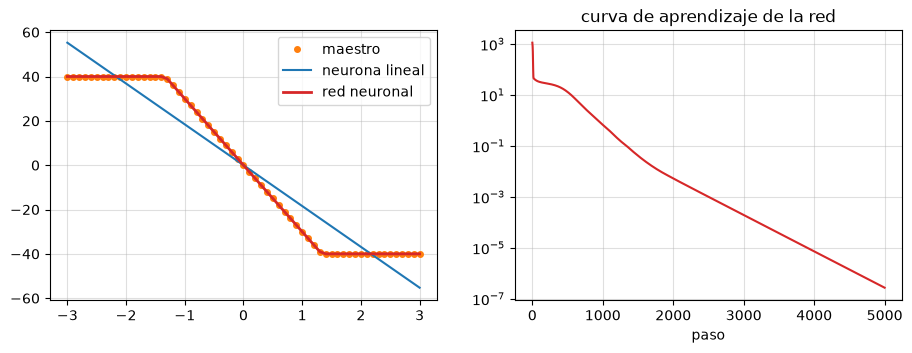

In [7]:
plt.figure(figsize=(11, 3.5))

plt.subplot(1, 2, 1)
plt.plot(inclinaciones, empujes_del_maestro, "o", color="tab:orange", markersize=4, label="maestro")
plt.plot(inclinaciones, w * inclinaciones + b, color="tab:blue", label="neurona lineal")
plt.plot(inclinaciones, predecir(inclinaciones), color="tab:red", linewidth=2, label="red neuronal")
plt.grid(True, alpha=0.4)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial, color="tab:red")
plt.yscale("log")
plt.grid(True, alpha=0.4)
plt.title("curva de aprendizaje de la red")
plt.xlabel("paso")

plt.show()

A la izquierda, la red (en rojo) pasa **exactamente** por los puntos del maestro, con sus dos esquinas, mientras la neurona lineal (en azul) se queda tiesa. A la
derecha, la curva de aprendizaje (en escala logarítmica, NB18): baja y baja hasta casi cero.

**Acabas de entrenar una red neuronal escribiendo tú mismo su retropropagación.** La mayoría de la gente que usa redes neuronales nunca lo ha hecho a mano: usa
bibliotecas que lo hacen solas (como PyTorch, que aprenderemos más adelante). Tú ya sabes qué hacen por dentro.


### Cuidado: a veces la red se atasca

Entrenar redes neuronales no siempre sale tan bien. Si repites el entrenamiento con una tasa un poco más alta, **0,01** (está en los ejercicios), la
pérdida **se queda atascada en torno a 11**, en vez de bajar a 0.

¿Qué pasa? Con pasos más bruscos al principio, los codos de las neuronas se colocan en **sitios poco útiles** (por ejemplo, varios codos casi en el mismo
lugar, y ninguno en una de las dos esquinas que hacen falta). Desde ahí, cualquier pequeño cambio empeora un poco las cosas antes de mejorarlas, y el
descenso por gradiente, que solo ve la pendiente bajo sus pies, **no sabe salir**. ¿Te suena? Es un **óptimo local** (NB04, NB17): un valle que no es el
más profundo.

Hay otro problema famoso, emparentado: las **neuronas muertas**. Si una neurona recibe un empujón tan fuerte que queda **apagada para todos los ejemplos**,
su pendiente es siempre 0 (la ReLU es plana a la izquierda), sus pesos ya no se mueven nunca, y la red pierde ese codo para siempre.

Las soluciones de los profesionales: tasas más prudentes, mejores formas de elegir los pesos iniciales, más neuronas de las estrictamente necesarias (para tener
codos de sobra), y variantes de la ReLU que no son del todo planas a la izquierda. Lo importante: **entrenar redes es un poco arte**, y la curva de aprendizaje es
tu mejor amiga para darte cuenta de que algo va mal.

## 7 · ¿Hasta dónde llega esto?

Con 2 codos construimos una forma de 3 tramos. Con más codos, formas más complicadas: cada codo nuevo añade una "esquina" donde la curva puede cambiar de
dirección. Con **suficientes** codos, se puede imitar **casi cualquier curva** tan bien como se quiera, igual que se puede dibujar un círculo con muchos trocitos
de recta muy cortos.

Los matemáticos lo demostraron en los años 80-90 con un resultado que se conoce como **teorema de aproximación universal**: una red con una capa oculta de
neuronas con activación puede aproximar casi cualquier función, si tiene neuronas suficientes. En la práctica, en vez de una capa oculta enorme, se usan
**varias capas** (redes "profundas", de ahí el nombre **aprendizaje profundo**, *deep learning*), que aprenden formas complicadas con muchas menos neuronas.

Y ahora une todas las piezas de la Parte 2:

- La **observación** es un vector (NB12). Cada **neurona** hace un producto escalar más un sesgo (NB13). Una **capa** es una matriz de pesos (NB14), y NumPy la
  calcula de golpe (NB15).
- Entre capa y capa va la **ReLU**: el codo que permite doblarse (hoy).
- Los pesos se ajustan **bajando por la pendiente** de la pérdida (NB16-17), calculando todas las pendientes de golpe con la **regla de la cadena** (NB18-19).


## 8 · La red de un humanoide de verdad

¿Cómo es la red neuronal que controla un humanoide entrenado con aprendizaje por refuerzo? Muy a menudo, algo así (las medidas exactas cambian de un proyecto a
otro, pero el tamaño típico es este):

```
   observación ──► capa 1 ──► ReLU ──► capa 2 ──► ReLU ──► capa de salida ──► acciones
     (348)        (256)                 (256)                    (17)
```

Contemos sus ruedecillas, con la regla del NB14 (salidas × entradas + salidas):


In [8]:
capa1 = 256 * 348 + 256
capa2 = 256 * 256 + 256
capa_salida = 17 * 256 + 17
print("Capa 1:", capa1, "| Capa 2:", capa2, "| Salida:", capa_salida)
print("Ruedecillas en total:", capa1 + capa2 + capa_salida)

Capa 1: 89344 | Capa 2: 65792 | Salida: 4369
Ruedecillas en total: 159505


**159.505 ruedecillas.** Frente a las 2 del palo de escoba, las 782 de la política lineal (NB14) o las 25 de la red de hoy (8 + 8 + 8 + 1).

Es una red "pequeña" para los estándares actuales (las redes que generan texto o imágenes tienen **miles de millones**), y sin embargo es capaz de aprender a
mantener en equilibrio y hacer andar a un cuerpo de 17 motores. Y todas sus ruedecillas se ajustan exactamente como hoy: hacia delante para predecir, hacia atrás
con la regla de la cadena para repartir la culpa, y un pasito cuesta abajo. Solo que hechas por una biblioteca, a toda velocidad, millones de veces.

Ya tienes todas las piezas matemáticas. Lo que falta es la última: cómo se calcula "la pérdida" cuando **no hay un maestro**, solo una recompensa. Eso es el
**aprendizaje por refuerzo** de verdad, y hacia allí vamos.


## 9 · Resumen de la lección

1. Una neurona lineal (y cualquier torre de capas lineales, porque multiplicar y multiplicar es multiplicar) **solo hace rectas**. Con el maestro que satura, se
   atasca en una pérdida de 81,5.
2. La **función de activación ReLU**, max(0, x), añade un **codo** a cada neurona. Sumando codos se construyen formas con esquinas: con **dos**, a mano, el maestro
   **exacto**.
3. Una **red neuronal**: entrada → **capa oculta** con ReLU → salida. Se entrena con descenso por gradiente y **retropropagación** (la regla de la cadena con un
   eslabón más: la pendiente de la ReLU es **1 si la neurona está encendida, 0 si apagada**). Nuestra red de 8 neuronas bajó la pérdida de 1.118 a casi 0.
4. Con una tasa demasiado alta (0,01), la red se atasca en un **óptimo local** (~11): los codos quedan mal colocados. Otro peligro conocido son las
   **neuronas muertas**. Entrenar es un poco arte: vigila la curva de aprendizaje.
5. Con suficientes codos se aproxima casi cualquier curva (**aproximación universal**); con varias capas, **aprendizaje profundo**. La red típica de un humanoide (348
   → 256 → 256 → 17) tiene **159.505** ruedecillas.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Lineal** | Que solo hace rectas: multiplicar y sumar. |
| **Función de activación** | La regla que se aplica a la salida de cada neurona para que la red pueda doblarse. |
| **ReLU** | La activación max(0, x): deja pasar lo positivo, convierte lo negativo en 0. Un "codo". |
| **Red neuronal** | Capas de neuronas con activación, una detrás de otra. |
| **Capa oculta** | Una capa entre la entrada y la salida. |
| **Neurona encendida / apagada** | Con z > 0 (deja pasar) / con z ≤ 0 (da 0). |
| **Neuronas muertas** | Neuronas apagadas para todos los ejemplos, que ya no aprenden. |
| **Valor absoluto (`np.abs`)** | Un número sin su signo: la distancia al cero. |
| **Aproximación universal** | Con suficientes neuronas, una red imita casi cualquier curva. |
| **Aprendizaje profundo (*deep learning*)** | Aprender con redes de muchas capas. |


## 10 · Ejercicios

**E1.** Calcula a mano: ReLU(5), ReLU(−3), ReLU(0), ReLU(2 − 7).

**E2.** En la red a mano del apartado 5, calcula el empuje para una inclinación de **0**, de **2** y de **−2**. ¿Coinciden con el maestro (−30 × inclinación,
recortado a ±40)?

**E3.** Una red tiene 10 entradas, una capa oculta de 32 neuronas y 4 salidas. ¿Cuántas ruedecillas tiene?

**E4.** Repite el entrenamiento de la red con tasa **0,01** (cambia `tasa = 0.003` por `tasa = 0.01` y vuelve a ejecutar la celda; ojo, también hay que volver a
crear los pesos al azar, que están en la misma celda). ¿En cuánto se queda la pérdida final?

**E5.** ¿Qué crees que pasaría si quitáramos la ReLU de la red (es decir, si usáramos `z` en vez de `relu(z)`)? ¿Podría bajar la pérdida de 81,5? Razónalo con el
apartado 3.

**E6.** **Reto.** Construye a mano, con codos, una red que imite al maestro "**tímido**": no empuja nada si la inclinación está entre −1 y 1 (zona muerta), y fuera
de ahí empuja −20 por cada grado que se pase. (Pista: necesitas un codo en +1 y otro en −1. Para el de −1, puedes usar ReLU(−inclinación − 1).)


<details>
<summary>▶ Solución E1</summary>

- ReLU(5) = **5** (positivo: pasa).
- ReLU(−3) = **0** (negativo: se convierte en 0).
- ReLU(0) = **0**.
- ReLU(2 − 7) = ReLU(−5) = **0**.
</details>

<details>
<summary>▶ Solución E2</summary>

- Inclinación 0: 40 − 30 × ReLU(4/3) + 30 × ReLU(−4/3) = 40 − 30 × 4/3 + 0 = 40 − 40 = **0**. Maestro: −30 × 0 = 0. ✓
- Inclinación 2: 40 − 30 × ReLU(10/3) + 30 × ReLU(2/3) = 40 − 100 + 20 = **−40**. Maestro: −60, recortado a −40. ✓
- Inclinación −2: 40 − 30 × ReLU(−2/3) + 30 × ReLU(−10/3) = 40 − 0 + 0 = **40**. Maestro: +60, recortado a 40. ✓
</details>

<details>
<summary>▶ Solución E3</summary>

Capa oculta: 32 × 10 + 32 = 352. Salida: 4 × 32 + 4 = 132. Total: **484** ruedecillas.
</details>

<details>
<summary>▶ Solución E4</summary>

Con tasa 0,01, la pérdida final se queda en torno a **11**, en vez de bajar a casi 0. Los primeros pasos, demasiado bruscos, colocan los codos en sitios poco
útiles, y la red cae en un **óptimo local** del que el descenso por gradiente no sabe salir (apartado 6). Curiosamente, ninguna neurona ha muerto (si lo
compruebas, todas siguen encendidas para algunos ejemplos): simplemente están **mal colocadas**. Vuelve a poner 0,003 para recuperar el buen resultado.
</details>

<details>
<summary>▶ Solución E5</summary>

Sin la ReLU, cada neurona oculta sería lineal, y la red entera sería una torre de capas lineales: **una recta** (apartado 3). Así que la mejor pérdida posible sería la
de la mejor recta: **81,5**, igual que la neurona lineal. Toda la capacidad de doblarse viene de la activación. Sin codos, da igual cuántas neuronas pongas.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
timido = -20 * relu(inclinaciones - 1) + 20 * relu(-inclinaciones - 1)

maestro_timido = np.where(inclinaciones > 1, -20 * (inclinaciones - 1),
                 np.where(inclinaciones < -1, -20 * (inclinaciones + 1), 0))
print(np.max(np.abs(timido - maestro_timido)))
```

- `-20 * relu(inclinaciones - 1)`: el codo en **+1**; a partir de ahí, empuja −20 por cada grado de más.
- `+20 * relu(-inclinaciones - 1)`: el codo en **−1**; por debajo de −1, ReLU(−i − 1) crece, y con el +20 empuja hacia el lado positivo (para enderezar).
- Entre −1 y 1, los dos codos están apagados: empuje 0, la zona muerta.

(`np.where(condición, a, b)` elige `a` donde la condición es cierta y `b` donde no: aquí solo sirve para fabricar el maestro y comparar.) La diferencia máxima sale 0:
imitación exacta, con dos codos.
</details>


## 11 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Con esta lección tienes **todas las piezas matemáticas** de una red neuronal: vectores, productos escalares, matrices, pendientes, gradientes, la regla de la cadena y
las activaciones. Y has entrenado una red escribiendo tú mismo cada línea de su aprendizaje. Eso es más de lo que entiende mucha gente que trabaja con inteligencia
artificial.

Antes de seguir, haremos una parada importante: un bloque de **ocho lecciones de Python "de verdad"** (NB20-NB27), para que domines el lenguaje como un profesional
(clases, ficheros, errores, tests, Git...), porque las herramientas que vienen están escritas con todo eso. Después, el siguiente paso será juntar las dos mitades del curso: las **redes neuronales** (lo que sabe hacer la mente) y el **aprendizaje por refuerzo** (cómo aprende sin maestro,
solo con recompensas). La gran pregunta será: si no hay un maestro que diga "aquí había que empujar tanto", **¿de dónde sale la pérdida?** La respuesta tiene que ver
con algo que ya intuyes desde el NB03: **hacer más probables las acciones que salieron bien**.
